In [13]:
# ===== 1. IMPORTS =====
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys

# Make the src/ package importable from within the notebooks/ subfolder.
sys.path.append("..")

# import constants and functions from our src/ modules to keep the notebook clean 
# and focused on the data.
from src.config import (
    SEED, TOP_K_FEATURES, POP_SIZE, N_GENERATIONS,
    MUTATION_RATE, CROSSOVER_RATE, TOURNAMENT_SIZE,
    EARLY_STOP_PATIENCE, MIN_IMPROVEMENT
)
from src.feature_prefilter import prefilter_features 
from src.ga_feature_selection import run_ga

In [14]:
# ===== 2. LOAD PRE-PROCESSED DATA =====
# use split and scaled data from 01_dataset_inspection.ipynb
with open("../data/processed/uci_small/uci_small_split_scaled.pkl", "rb") as f:
    X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)

In [15]:
# ===== 3. PREFILTER FEATURES WITH MUTUAL INFORMATION =====
# quick prefiltering step to remove obviously irrelevant features and speed up the GA.
X_train_ga, X_test_ga, selected_prefilter_features, mi_series = prefilter_features(
    X_train_scaled,
    X_test_scaled,
    y_train,
    k=TOP_K_FEATURES,
    seed=SEED
)

print("Features before prefilter:", X_train_scaled.shape[1])
print("Features after prefilter:", X_train_ga.shape[1])

# Show the top-20 features
mi_series.head(20)

Features before prefilter: 111
Features after prefilter: 50


directory_length             0.306832
qty_slash_url                0.297372
qty_slash_directory          0.294809
qty_dot_directory            0.262343
file_length                  0.261612
qty_dot_file                 0.253369
qty_hyphen_directory         0.247738
length_url                   0.241083
qty_comma_file               0.236752
qty_hashtag_file             0.236265
qty_tilde_file               0.235968
qty_plus_directory           0.234728
qty_equal_directory          0.234522
qty_plus_file                0.234382
qty_asterisk_file            0.234368
qty_underline_file           0.234155
qty_exclamation_directory    0.234100
qty_dollar_file              0.234001
qty_slash_file               0.233891
qty_asterisk_directory       0.233809
dtype: float64

In [16]:
# ===== 4. RUN THE GENETIC ALGORITHM =====
# run
best_chromosome, best_fitness, selected_features, best_hist, avg_hist = run_ga(
    X_train_ga,
    y_train,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    tournament_size=TOURNAMENT_SIZE,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_improvement=MIN_IMPROVEMENT,
    seed=SEED
)

print("Best fitness:", best_fitness)
print("Selected feature count:", len(selected_features))
print(selected_features)

KeyboardInterrupt: 

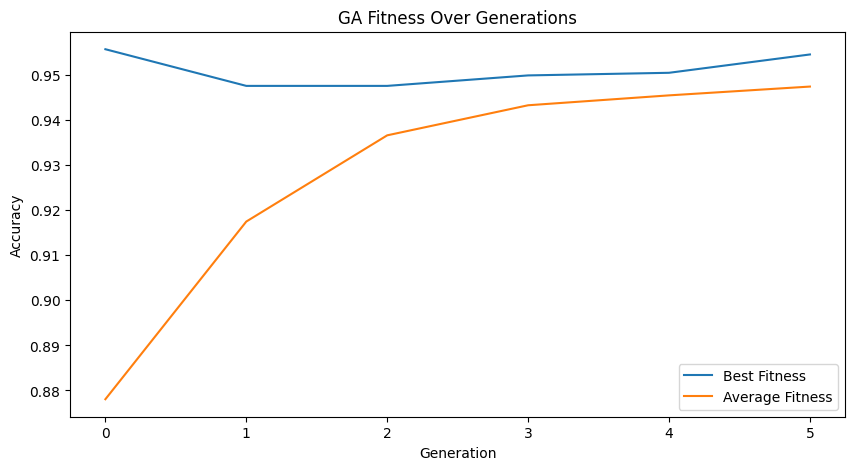

In [ ]:
# ===== 5. PLOT GA CONVERGENCE =====
# plot the best and average fitness over generations to visualize convergence.
plt.figure(figsize=(10, 5))
plt.plot(best_hist, label="Best Fitness")
plt.plot(avg_hist, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("GA Fitness Over Generations")
plt.legend()
plt.show()

In [ ]:
# ===== 6. SAVE GA RESULTS =====
# Save the selected features and GA history for later use in model evaluation and plotting.
#
# dataset1_selected_features.pkl  -> list of feature name strings chosen by the GA; 
# used to slice X_train/X_test when evaluating the final model.
#
# dataset1_ga_history.pkl  -> (best_hist, avg_hist) lists; used to reproduce the 
# convergence plot later.
with open("../data/processed/uci_small/uci_small_selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

with open("../data/processed/uci_small/uci_small_ga_history.pkl", "wb") as f:
    pickle.dump((best_hist, avg_hist), f)